# NSU BDA. 2024 Accidents
Соревнование для студенттов курса АБМД, ФИТ НГУ 2024

Студент: Митюшин Владимир 24221

In [657]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

Загрузим данные

In [658]:
X_train = pd.read_csv('X_train.csv', index_col=0)
X_testFinal = pd.read_csv('X_test.csv', index_col=0)
Y_train = pd.read_csv('Y_train.csv', index_col=0)

Выведем информацию по датасетам

In [659]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 499056 entries, 241270 to 121958
Data columns (total 35 columns):
 #   Column                                   Non-Null Count   Dtype 
---  ------                                   --------------   ----- 
 0   accident_index                           499056 non-null  object
 1   vehicle_reference                        499056 non-null  int64 
 2   casualty_class                           499056 non-null  int64 
 3   sex_of_casualty                          499056 non-null  int64 
 4   age_of_casualty                          499056 non-null  int64 
 5   age_band_of_casualty                     499056 non-null  int64 
 6   pedestrian_location                      499056 non-null  int64 
 7   pedestrian_movement                      499056 non-null  int64 
 8   car_passenger                            499056 non-null  int64 
 9   bus_or_coach_passenger                   499056 non-null  int64 
 10  pedestrian_road_maintenance_worker       499

In [660]:
Y_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 499056 entries, 241270 to 121958
Data columns (total 1 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   casualty_severity  499056 non-null  int64
dtypes: int64(1)
memory usage: 7.6 MB


Посмотрим более подробно на целевой признак

In [661]:
print("min: ", Y_train['casualty_severity'].min())
print("max: ", Y_train['casualty_severity'].max())
print("unique: ", Y_train['casualty_severity'].unique())

min:  1
max:  3
unique:  [3 2 1]


### Исходя из возможных значений целевого признака понимаем, что имеем задачу классификации

## Очистка и подготовка данных

In [662]:
X_train.describe()

,vehicle_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_home_area_type,casualty_distance_banding,vehicle_type,vehicle_manoeuvre,vehicle_left_hand_drive,engine_capacity_cc,age_of_vehicle,police_force,first_road_class,first_road_number,road_type,speed_limit,junction_detail,junction_control,second_road_class,second_road_number,pedestrian_crossing_human_control,pedestrian_crossing_physical_facilities,light_conditions,weather_conditions,road_surface_conditions
count,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000
mean,1.457009,1.472198,1.366891,36.823471,6.312548,0.758696,0.613450,0.231964,0.050407,0.025949,7.621940,1.067680,1.586858,9.251459,19.397414,1.278187,1233.934146,6.178537,28.349796,4.144018,801.286110,5.233060,37.549017,3.777957,1.678210,2.994840,223.466781,0.321896,1.104309,2.056154,1.638289,1.371584
std,2.323518,0.725208,0.529874,19.526246,2.453729,2.144590,1.963437,0.627427,0.436082,0.232426,10.532901,0.919608,1.424478,11.366400,21.870117,1.461020,1294.323320,6.515864,24.402768,1.470346,1593.954718,1.672408,14.742382,11.998430,2.516433,2.758235,935.872042,1.637604,2.372924,1.734888,1.790234,0.930508
min,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,1.000000,0.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,1.000000,1.000000,1.000000,22.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,8.000000,9.000000,1.000000,108.000000,0.000000,5.000000,3.000000,0.000000,6.000000,30.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000,34.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,1.000000,9.000000,18.000000,1.000000,1299.000000,5.000000,23.000000,4.000000,38.000000,6.000000,30.000000,1.000000,2.000000,3.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
75%,2.000000,2.000000,2.000000,50.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,2.000000,9.000000,18.000000,1.000000,1796.000000,11.000000,45.000000,6.000000,563.000000,6.000000,50.000000,3.000000,4.000000,6.000000,0.000000,0.000000,0.000000,4.000000,1.000000,2.000000
max,999.000000,3.000000,9.000000,102.000000,11.000000,10.000000,9.000000,9.000000,9.000000,2.000000,99.000000,3.000000,5.000000,99.000000,99.000000,9.000000,29980.000000,122.000000,99.000000,6.000000,9176.000000,9.000000,70.000000,99.000000,9.000000,6.000000,9999.000000,9.000000,9.000000,7.000000,9.000000,9.000000


In [663]:
df = X_train.copy()

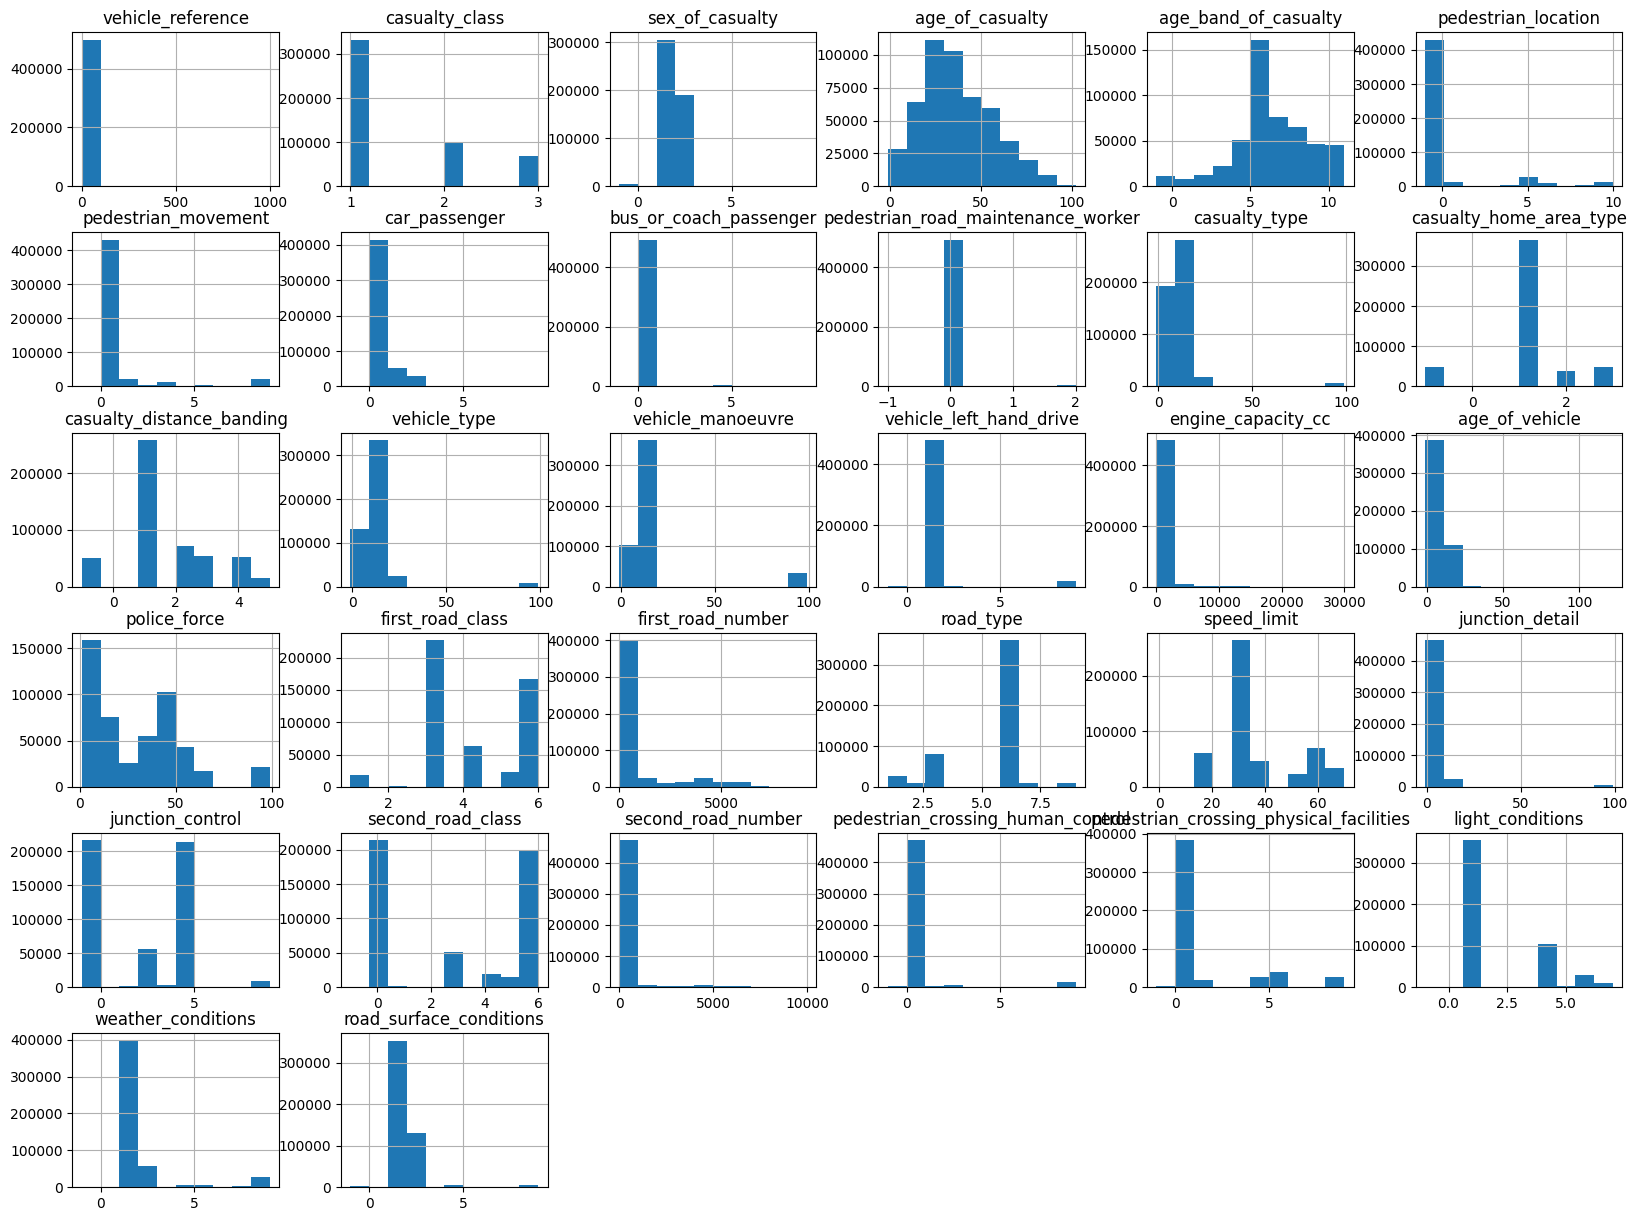

In [664]:
df.hist(figsize=(20, 15));

In [665]:
df[df.select_dtypes('number').columns].corr().style.background_gradient(cmap='coolwarm')

,vehicle_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_home_area_type,casualty_distance_banding,vehicle_type,vehicle_manoeuvre,vehicle_left_hand_drive,engine_capacity_cc,age_of_vehicle,police_force,first_road_class,first_road_number,road_type,speed_limit,junction_detail,junction_control,second_road_class,second_road_number,pedestrian_crossing_human_control,pedestrian_crossing_physical_facilities,light_conditions,weather_conditions,road_surface_conditions
vehicle_reference,1.000000,-0.064538,0.007993,0.010320,0.012310,-0.064516,-0.056104,0.006789,-0.008412,-0.019918,0.016855,0.007335,0.011052,-0.010642,-0.048783,-0.034533,-0.012124,-0.016528,0.013586,-0.023168,0.003192,-0.021420,0.023898,-0.020136,0.002722,0.008913,0.006515,-0.029889,-0.025779,-0.016973,-0.011586,-0.015192
casualty_class,-0.064538,1.000000,0.138682,-0.113040,-0.164023,0.745226,0.658183,0.266363,0.084127,0.235202,-0.212592,-0.102559,-0.122670,0.105022,-0.071103,0.021740,0.149160,0.029881,-0.024235,0.106220,-0.013121,0.057076,-0.149936,-0.024210,-0.048104,-0.031913,-0.010312,-0.022693,0.050426,0.015356,0.013428,-0.015618
sex_of_casualty,0.007993,0.138682,1.000000,0.077917,0.087495,0.035467,0.035587,0.097928,0.064566,0.009888,-0.003672,0.043721,-0.004959,0.016618,-0.140961,-0.087048,0.088529,0.064268,0.062734,0.002982,0.006840,-0.011969,0.036967,-0.049798,-0.022966,-0.013542,0.010214,-0.080135,-0.051846,-0.054690,-0.019117,-0.034445
age_of_casualty,0.010320,-0.113040,0.077917,1.000000,0.964787,-0.020352,-0.008440,-0.180588,0.030034,-0.015949,-0.002025,0.106334,0.079747,-0.008282,-0.087622,-0.063010,0.073417,0.021017,0.065464,-0.051619,0.010742,-0.015170,0.071706,-0.032687,0.000132,0.000200,0.011941,-0.051863,-0.050625,-0.090266,-0.032161,-0.025730
age_band_of_casualty,0.012310,-0.164023,0.087495,0.964787,1.000000,-0.046647,-0.029762,-0.219288,0.008016,-0.020851,0.001552,0.117173,0.102986,-0.015421,-0.090201,-0.083140,0.054947,0.017855,0.060458,-0.064643,0.013139,-0.024699,0.078952,-0.031170,0.002340,0.001699,0.012778,-0.054228,-0.051761,-0.067623,-0.034354,-0.022301
pedestrian_location,-0.064516,0.745226,0.035467,-0.020352,-0.046647,1.000000,0.831269,-0.130792,-0.040893,0.276384,-0.255984,-0.060115,-0.116815,0.087373,-0.036179,0.019712,0.035922,-0.033492,-0.028434,0.163233,-0.030952,0.086717,-0.188522,-0.003056,-0.032924,-0.026476,-0.025989,-0.002253,0.013086,-0.006272,0.027217,-0.011143
pedestrian_movement,-0.056104,0.658183,0.035587,-0.008440,-0.029762,0.831269,1.000000,-0.115510,-0.036115,0.235362,-0.226079,-0.050398,-0.098291,0.096972,-0.016300,0.039921,0.017117,-0.046026,-0.035841,0.135869,-0.026100,0.078145,-0.167795,0.008313,-0.035383,-0.029566,-0.024095,0.016960,0.034457,-0.003069,0.038065,-0.002432
car_passenger,0.006789,0.266363,0.097928,-0.180588,-0.219288,-0.130792,-0.115510,1.000000,-0.039447,-0.041276,0.050885,-0.043761,0.015827,-0.005849,-0.001950,0.073351,0.082044,0.095482,0.012489,-0.047822,0.007301,-0.022894,0.088219,-0.004561,-0.023501,-0.030079,0.010561,0.008350,-0.014153,0.056997,0.002998,0.025636
bus_or_coach_passenger,-0.008412,0.084127,0.064566,0.030034,0.008016,-0.040893,-0.036115,-0.039447,1.000000,-0.012905,0.037135,-0.039746,-0.042963,0.017841,-0.025986,-0.009284,0.357557,0.007974,-0.036402,-0.019216,-0.000812,-0.002780,-0.051193,-0.001769,0.000350,0.006365,-0.001773,0.003708,0.026543,-0.031053,0.004472,0.001543
pedestrian_road_maintenance_worker,-0.019918,0.235202,0.009888,-0.015949,-0.020851,0.276384,0.235362,-0.041276,-0.012905,1.000000,-0.080789,-0.028672,-0.041154,0.026373,-0.034641,-0.019983,0.008794,-0.006473,-0.011629,0.056095,0.006432,0.022372,-0.056332,-0.011048,-0.010610,-0.002510,0.001566,-0.013048,0.006377,0.000128,0.007687,-0.009117


In [666]:
drop_indexes = df.index[df['vehicle_reference'] > 20].tolist()
drop_indexes= drop_indexes + df.index[df['age_of_vehicle'] > 25].tolist()
df.drop(drop_indexes, inplace=True)
Y_train.drop(drop_indexes, inplace=True)

df['sex_of_casualty'] = df['sex_of_casualty'].replace(9, -1)
df['car_passenger'] = df['car_passenger'].replace(9, -1)
df['casualty_type'] = df['casualty_type'].replace([3, 4, 5, 22, 23, 97, 103, 104, 105, 106], 2).replace([20, 21, 98, 113], 19)

df[df.select_dtypes('number').columns] = df[df.select_dtypes('number').columns].replace(-1, 0)
# df.fillna(df.median(axis=0, numeric_only=True), inplace=True)
df[X_train.select_dtypes('O').columns] = X_train.select_dtypes('O')
df.describe()

,vehicle_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_home_area_type,casualty_distance_banding,vehicle_type,vehicle_manoeuvre,vehicle_left_hand_drive,engine_capacity_cc,age_of_vehicle,police_force,first_road_class,first_road_number,road_type,speed_limit,junction_detail,junction_control,second_road_class,second_road_number,pedestrian_crossing_human_control,pedestrian_crossing_physical_facilities,light_conditions,weather_conditions,road_surface_conditions
count,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.0000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000
mean,1.449964,1.473234,1.374716,36.805348,6.329737,0.760878,0.615106,0.226368,0.051016,0.027359,7.069598,1.165128,1.684950,9.259631,19.421290,1.280769,1234.108539,6.275825,28.314019,4.144252,800.691008,5.232447,37.519224,3.786188,2.112153,2.997564,224.0710,0.330892,1.114702,2.057362,1.639338,1.377003
std,0.593538,0.725776,0.499441,19.473195,2.391772,2.147327,1.965765,0.546278,0.436492,0.229656,9.218352,0.724268,1.265541,11.371320,21.907533,1.462240,1294.941821,5.893691,24.407437,1.470665,1593.561288,1.673314,14.733615,12.024645,2.064552,2.756780,936.2559,1.637034,2.370335,1.735246,1.791848,0.921765
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,22.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,8.000000,9.000000,1.000000,108.000000,0.000000,5.000000,3.000000,0.000000,6.000000,30.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,1.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000,34.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,1.000000,9.000000,18.000000,1.000000,1299.000000,5.000000,23.000000,4.000000,38.000000,6.000000,30.000000,1.000000,2.000000,3.000000,0.0000,0.000000,0.000000,1.000000,1.000000,1.000000
75%,2.000000,2.000000,2.000000,50.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,2.000000,9.000000,18.000000,1.000000,1796.000000,11.000000,45.000000,6.000000,562.000000,6.000000,50.000000,3.000000,4.000000,6.000000,0.0000,0.000000,0.000000,4.000000,1.000000,2.000000
max,20.000000,3.000000,2.000000,102.000000,11.000000,10.000000,9.000000,2.000000,9.000000,2.000000,99.000000,3.000000,5.000000,99.000000,99.000000,9.000000,29980.000000,25.000000,99.000000,6.000000,9176.000000,9.000000,70.000000,99.000000,9.000000,6.000000,9999.0000,9.000000,9.000000,7.000000,9.000000,9.000000


In [667]:
df.drop(columns='accident_index', inplace=True)

In [668]:
df = df.drop(columns=['age_of_casualty', 'pedestrian_movement', 'second_road_number', 'junction_control', 'pedestrian_crossing_human_control', 'engine_capacity_cc'])

In [669]:
df = df.drop(columns=['bus_or_coach_passenger', 'pedestrian_road_maintenance_worker', 'vehicle_left_hand_drive', 'vehicle_reference', 'junction_detail']) # , 'vehicle_type'

In [670]:
df.describe()

,casualty_class,sex_of_casualty,age_band_of_casualty,pedestrian_location,car_passenger,casualty_type,casualty_home_area_type,casualty_distance_banding,vehicle_type,vehicle_manoeuvre,age_of_vehicle,police_force,first_road_class,first_road_number,road_type,speed_limit,second_road_class,pedestrian_crossing_physical_facilities,light_conditions,weather_conditions,road_surface_conditions
count,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000
mean,1.473234,1.374716,6.329737,0.760878,0.226368,7.069598,1.165128,1.684950,9.259631,19.421290,6.275825,28.314019,4.144252,800.691008,5.232447,37.519224,2.997564,1.114702,2.057362,1.639338,1.377003
std,0.725776,0.499441,2.391772,2.147327,0.546278,9.218352,0.724268,1.265541,11.371320,21.907533,5.893691,24.407437,1.470665,1593.561288,1.673314,14.733615,2.756780,2.370335,1.735246,1.791848,0.921765
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,5.000000,0.000000,0.000000,1.000000,1.000000,1.000000,8.000000,9.000000,0.000000,5.000000,3.000000,0.000000,6.000000,30.000000,0.000000,0.000000,1.000000,1.000000,1.000000
50%,1.000000,1.000000,6.000000,0.000000,0.000000,9.000000,1.000000,1.000000,9.000000,18.000000,5.000000,23.000000,4.000000,38.000000,6.000000,30.000000,3.000000,0.000000,1.000000,1.000000,1.000000
75%,2.000000,2.000000,8.000000,0.000000,0.000000,9.000000,1.000000,2.000000,9.000000,18.000000,11.000000,45.000000,6.000000,562.000000,6.000000,50.000000,6.000000,0.000000,4.000000,1.000000,2.000000
max,3.000000,2.000000,11.000000,10.000000,2.000000,99.000000,3.000000,5.000000,99.000000,99.000000,25.000000,99.000000,6.000000,9176.000000,9.000000,70.000000,6.000000,9.000000,7.000000,9.000000,9.000000


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
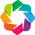

BokehModel(combine_events=True, render_bundle={'docs_json': {'5e59f961-7f5c-42c7-b2a1-b12167c8fa88': {'version…

In [671]:
import holoviews as hv
from holoviews import dim
from holoviews import opts
hv.extension('bokeh')

def f(x):
    return hv.BoxWhisker(df[x]).opts(height=120, responsive=True, toolbar='above', invert_axes=True, tools=['hover'])

hv.DynamicMap(f, kdims=['x']).redim.values(x=df.select_dtypes('number').columns)

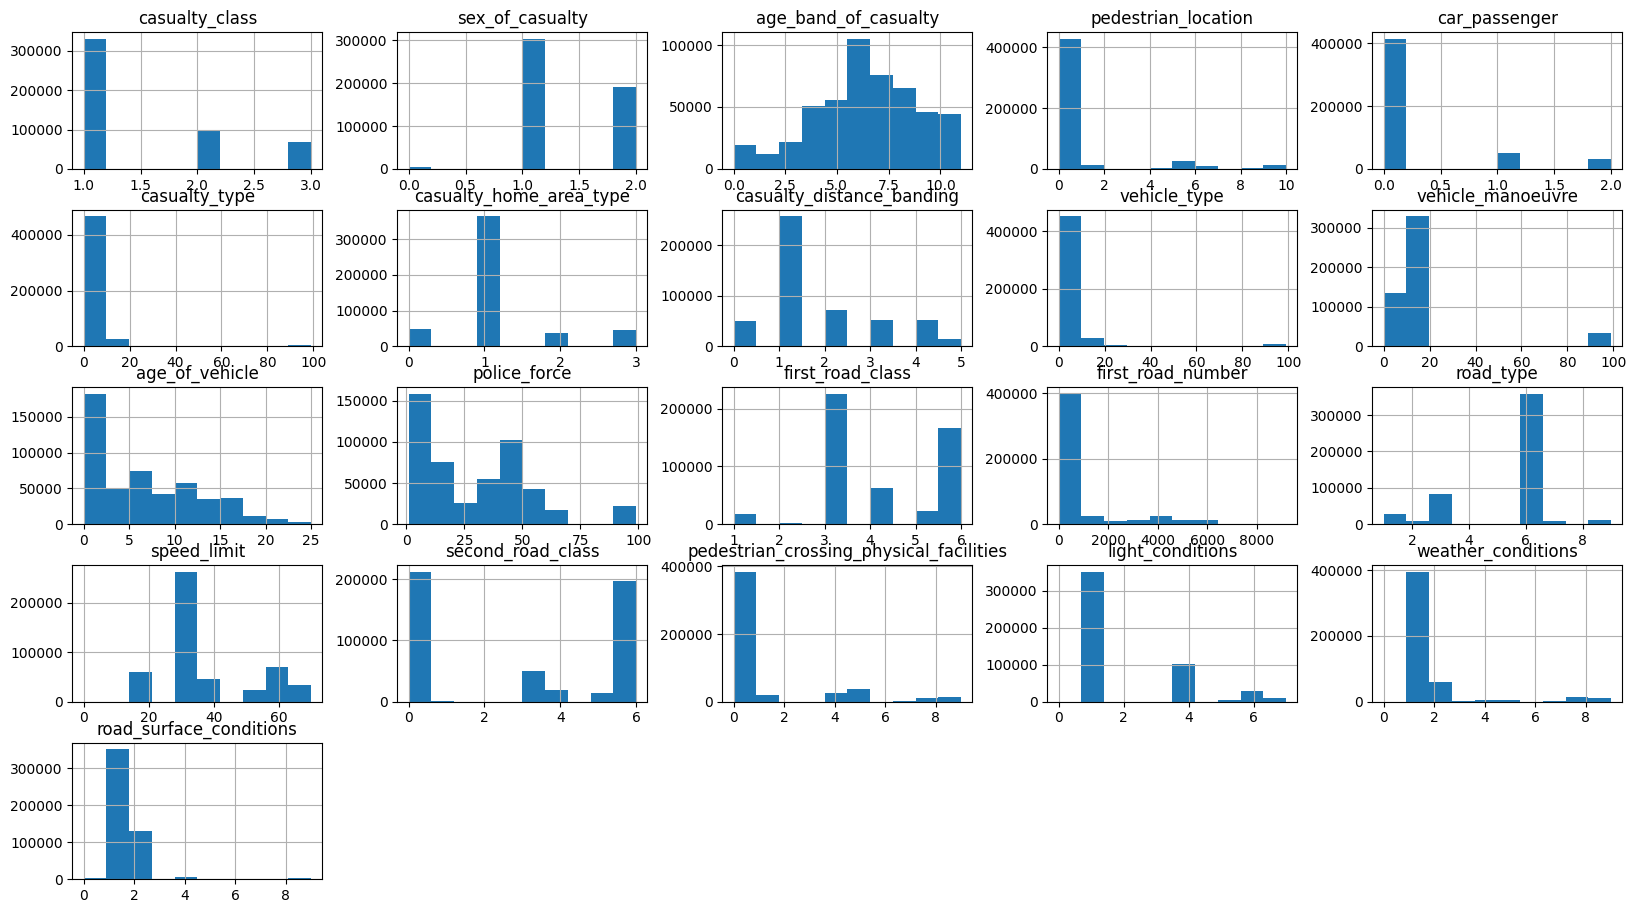

In [672]:
df.hist(figsize=(20, 11));

### Посмотрим на категориальные признаки

In [673]:
df.describe(include='O')

,generic_make_model,local_authority_highway
count,496651,496651
unique,1127,210
top,-1,E10000016
freq,131363,16737


In [674]:
df['generic_make_model'] = df['generic_make_model'].str.split(n=1).str[0].str.upper()
display(df['generic_make_model'].value_counts(dropna=False))

generic_make_model
-1            131363
FORD           43959
VAUXHALL       36307
VOLKSWAGEN     28299
HONDA          25694
               ...  
CASE               7
OPEL               6
PROTON             6
VALTRA             5
VESPA              4
Name: count, Length: 114, dtype: int64

In [675]:
display(df['local_authority_highway'].value_counts(dropna=False))

local_authority_highway
E10000016    16737
E10000030    12790
E10000012    11310
E08000025    11187
E10000017    10806
             ...  
EHEATHROW       98
S12000013       75
S12000023       63
S12000027       62
E06000053        6
Name: count, Length: 210, dtype: int64

In [676]:
df['local_authority_highway'] = df['local_authority_highway'].str[:4]
display(df['local_authority_highway'].value_counts(dropna=False))

local_authority_highway
E100    158518
E060    115077
E090    100761
E080     83493
S120     21799
W060     16905
EHEA        98
Name: count, dtype: int64

In [677]:
# df.drop(columns=['local_authority_highway', 'generic_make_model'], inplace=True)

In [678]:
one_hot = pd.get_dummies(df.select_dtypes('O'), prefix=df.select_dtypes('O').columns, dtype=bool)
df = pd.concat([one_hot, df.select_dtypes('number'), df.select_dtypes('bool')], axis=1)

df.describe()

,casualty_class,sex_of_casualty,age_band_of_casualty,pedestrian_location,car_passenger,casualty_type,casualty_home_area_type,casualty_distance_banding,vehicle_type,vehicle_manoeuvre,age_of_vehicle,police_force,first_road_class,first_road_number,road_type,speed_limit,second_road_class,pedestrian_crossing_physical_facilities,light_conditions,weather_conditions,road_surface_conditions
count,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000,496651.000000
mean,1.473234,1.374716,6.329737,0.760878,0.226368,7.069598,1.165128,1.684950,9.259631,19.421290,6.275825,28.314019,4.144252,800.691008,5.232447,37.519224,2.997564,1.114702,2.057362,1.639338,1.377003
std,0.725776,0.499441,2.391772,2.147327,0.546278,9.218352,0.724268,1.265541,11.371320,21.907533,5.893691,24.407437,1.470665,1593.561288,1.673314,14.733615,2.756780,2.370335,1.735246,1.791848,0.921765
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,5.000000,0.000000,0.000000,1.000000,1.000000,1.000000,8.000000,9.000000,0.000000,5.000000,3.000000,0.000000,6.000000,30.000000,0.000000,0.000000,1.000000,1.000000,1.000000
50%,1.000000,1.000000,6.000000,0.000000,0.000000,9.000000,1.000000,1.000000,9.000000,18.000000,5.000000,23.000000,4.000000,38.000000,6.000000,30.000000,3.000000,0.000000,1.000000,1.000000,1.000000
75%,2.000000,2.000000,8.000000,0.000000,0.000000,9.000000,1.000000,2.000000,9.000000,18.000000,11.000000,45.000000,6.000000,562.000000,6.000000,50.000000,6.000000,0.000000,4.000000,1.000000,2.000000
max,3.000000,2.000000,11.000000,10.000000,2.000000,99.000000,3.000000,5.000000,99.000000,99.000000,25.000000,99.000000,6.000000,9176.000000,9.000000,70.000000,6.000000,9.000000,7.000000,9.000000,9.000000


In [679]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 496651 entries, 241270 to 121958
Columns: 142 entries, generic_make_model_-1 to road_surface_conditions
dtypes: bool(121), int64(21)
memory usage: 140.7 MB


## Перейдём к обучению

In [680]:
X_testFinal = X_testFinal.reindex(df.columns, axis=1)
X_testFinal.describe()

,generic_make_model_-1,generic_make_model_ABARTH,generic_make_model_AJS,generic_make_model_ALEXANDER,generic_make_model_ALFA,generic_make_model_APRILIA,generic_make_model_AUDI,generic_make_model_BENELLI,generic_make_model_BENTLEY,generic_make_model_BMW,generic_make_model_BYD,generic_make_model_CAETANO,generic_make_model_CASE,generic_make_model_CHEVROLET,generic_make_model_CHRYSLER,generic_make_model_CITROEN,generic_make_model_CLAAS,generic_make_model_CUPRA,generic_make_model_DACIA,generic_make_model_DAEWOO,generic_make_model_DAF,generic_make_model_DAIHATSU,generic_make_model_DENNIS,generic_make_model_DERBI,generic_make_model_DODGE,generic_make_model_DS,generic_make_model_DUCATI,generic_make_model_FENDT,generic_make_model_FIAT,generic_make_model_FORD,generic_make_model_GILERA,generic_make_model_HARLEY-DAVIDSON,generic_make_model_HONDA,generic_make_model_HUSQVARNA,generic_make_model_HYOSUNG,generic_make_model_HYUNDAI,generic_make_model_INFINITI,generic_make_model_ISUZU,generic_make_model_IVECO,generic_make_model_JAGUAR,...,generic_make_model_UM,generic_make_model_VALTRA,generic_make_model_VAUXHALL,generic_make_model_VDL,generic_make_model_VESPA,generic_make_model_VMOTO,generic_make_model_VOLKSWAGEN,generic_make_model_VOLVO,generic_make_model_WRIGHTBUS,generic_make_model_YAMAHA,generic_make_model_ZNEN,generic_make_model_ZONTES,local_authority_highway_E060,local_authority_highway_E080,local_authority_highway_E090,local_authority_highway_E100,local_authority_highway_EHEA,local_authority_highway_S120,local_authority_highway_W060,casualty_class,sex_of_casualty,age_band_of_casualty,pedestrian_location,car_passenger,casualty_type,casualty_home_area_type,casualty_distance_banding,vehicle_type,vehicle_manoeuvre,age_of_vehicle,police_force,first_road_class,first_road_number,road_type,speed_limit,second_road_class,pedestrian_crossing_physical_facilities,light_conditions,weather_conditions,road_surface_conditions
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.00000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.470322,1.366873,6.305587,0.745834,0.232699,7.616548,1.068289,1.587892,9.234791,19.306639,6.18414,28.323892,4.149598,796.766651,5.238975,37.547730,3.008446,1.095220,2.051848,1.634257,1.371369
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.722688,0.532466,2.455111,2.123633,0.626563,10.439010,0.917274,1.424338,11.294774,21.728723,6.47909,24.336775,1.469986,1585.718521,1.665436,14.710353,2.759564,2.362987,1.732798,1.787258,0.933177
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.00000,1.000000,1.000000,0.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [681]:
Y_train = Y_train.apply(lambda y: y-1)

X_train, X_test, y_train, y_test = train_test_split(df, Y_train, random_state=42)
print(X_train.shape, y_train.shape)

(372488, 142) (372488, 1)


In [682]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [683]:
print(X_train.shape, X_testFinal.shape)

(372488, 142) (166352, 142)


In [710]:
from xgboost import XGBClassifier

model = XGBClassifier(n_estimators = 200, max_depth=7, objective='multi: softmax', num_class=3, random_state=42)
model.fit(X_train, y_train.values.ravel())

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None, num_class=3,
              num_parallel_tree=None, ...)

In [724]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [725]:
f1_train = f1_score(y_train, y_pred_train, average='macro')
f1_test = f1_score(y_test, y_pred_test, average='macro')
print(f1_train, f1_test)

0.47613728817348794 0.3798778349021908


In [ ]:
# y_predicted_Final = model.predict(X_testFinal)
# y_predicted_Final = y_predicted_Final +1

# print(y_predicted_Final)

[2 2 2 ... 3 2 2]


In [727]:
# my_file = open("rf_0.38.csv", "w+")

# my_file.write("Id,casualty_severity\n")
# my_i = 0
# for i, row in X_testFinal.iterrows():
#     my_file.write(f"{i}, {y_predicted_Final[my_i]}\n")
#     my_i = my_i+1
# my_file.close()